In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.5 MB/s eta 0:00:00


In [ ]:
# Import semua library yang dibutuhkan
import pandas as pd
import numpy as np
from google_play_scraper import reviews, Sort

# Library preprocessing
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Library machine learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, f1_score, accuracy_score

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# Scraping ulasan BCA Mobile
print("Scraping BCA Mobile... tunggu sebentar")

hasil_bca, _ = reviews(
    'com.bca',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)

df_bca = pd.DataFrame(hasil_bca)
df_bca['aplikasi'] = 'BCA Mobile'
print(f"✅ Berhasil: {len(df_bca)} ulasan BCA Mobile")

Scraping BCA Mobile... tunggu sebentar
✅ Berhasil: 2000 ulasan BCA Mobile


In [ ]:
# Scraping ulasan Mandiri Online
print("Scraping Mandiri Online... tunggu sebentar")

hasil_mandiri, _ = reviews(
    'com.bankmandiri.mandirionline',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)

df_mandiri = pd.DataFrame(hasil_mandiri)
df_mandiri['aplikasi'] = 'Mandiri Online'
print(f"✅ Berhasil: {len(df_mandiri)} ulasan Mandiri Online")

Scraping Mandiri Online... tunggu sebentar
✅ Berhasil: 2000 ulasan Mandiri Online


In [ ]:
# Scraping ulasan BRImo
print("Scraping BRImo... tunggu sebentar")

hasil_brimo, _ = reviews(
    'com.bri.britama',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)

df_brimo = pd.DataFrame(hasil_brimo)
df_brimo['aplikasi'] = 'BRImo'
print(f"✅ Berhasil: {len(df_brimo)} ulasan BRImo")

Scraping BRImo... tunggu sebentar
✅ Berhasil: 0 ulasan BRImo


In [ ]:
# Scraping ulasan BRImo - ID yang benar
print("Scraping BRImo... tunggu sebentar")

hasil_brimo, _ = reviews(
    'id.co.bri.brimo',    # ← ganti ini
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)

df_brimo = pd.DataFrame(hasil_brimo)
df_brimo['aplikasi'] = 'BRImo'
print(f"✅ Berhasil: {len(df_brimo)} ulasan BRImo")

Scraping BRImo... tunggu sebentar
✅ Berhasil: 2000 ulasan BRImo


In [ ]:
# Gabungkan semua data
df_semua = pd.concat([df_bca, df_mandiri, df_brimo], ignore_index=True)

# Pilih kolom yang dibutuhkan
df_bersih = df_semua[['userName', 'content', 'score', 'at', 'aplikasi']].copy()

# Rename kolom
df_bersih.columns = ['nama_user', 'ulasan', 'rating', 'tanggal', 'aplikasi']

# Labeling sentimen berdasarkan rating
def label_sentimen(rating):
    if rating >= 4:
        return 'positif'
    elif rating == 3:
        return 'netral'
    else:
        return 'negatif'

df_bersih['sentimen'] = df_bersih['rating'].apply(label_sentimen)

# Cek hasil
print(f"Total data: {len(df_bersih)} ulasan")
print("\nDistribusi per aplikasi:")
print(df_bersih['aplikasi'].value_counts())
print("\nDistribusi sentimen:")
print(df_bersih['sentimen'].value_counts())

# Simpan ke CSV
df_bersih.to_csv('dataset_ulasan_banking.csv', index=False)
print("\n✅ Data berhasil disimpan!")

Total data: 6000 ulasan

Distribusi per aplikasi:
aplikasi
BCA Mobile        2000
Mandiri Online    2000
BRImo             2000
Name: count, dtype: int64

Distribusi sentimen:
sentimen
positif    4184
negatif    1540
netral      276
Name: count, dtype: int64

✅ Data berhasil disimpan!


In [ ]:
from google.colab import files
files.download('dataset_ulasan_banking.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Install library stemming bahasa Indonesia
!pip install PySastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 5.3 MB/s eta 0:00:00


In [ ]:
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import re

# Inisialisasi stemmer dan stopword bahasa Indonesia
factory = StemmerFactory()
stemmer = factory.create_stemmer()

stop_factory = StopWordRemoverFactory()
stopword = stop_factory.create_stop_word_remover()

def preprocessing(teks):
    # 1. Lowercase
    teks = teks.lower()
    # 2. Hapus angka, simbol, emoji
    teks = re.sub(r'[^a-zA-Z\s]', '', teks)
    # 3. Hapus spasi berlebih
    teks = re.sub(r'\s+', ' ', teks).strip()
    # 4. Stopword removal
    teks = stopword.remove(teks)
    # 5. Stemming
    teks = stemmer.stem(teks)
    return teks

print("✅ Fungsi preprocessing siap!")

✅ Fungsi preprocessing siap!


In [ ]:
# Load dataset yang sudah disimpan
df = pd.read_csv('dataset_ulasan_banking.csv')

# Jalankan preprocessing
print("Preprocessing sedang berjalan... ini butuh beberapa menit")
df['ulasan_bersih'] = df['ulasan'].apply(preprocessing)

print(f"✅ Preprocessing selesai!")
print(f"Total data: {len(df)}")
print("\nContoh hasil preprocessing:")
print(df[['ulasan', 'ulasan_bersih', 'sentimen']].head(5))

Preprocessing sedang berjalan... ini butuh beberapa menit
✅ Preprocessing selesai!
Total data: 6000

Contoh hasil preprocessing:
                                              ulasan  \
0                                               good   
1                  Super mudah dan cepat By. BCA sih   
2                                        good besttt   
3                                            mantaap   
4  mbankingku ke bobolan ilang 200k tolong BCA di...   

                            ulasan_bersih sentimen  
0                                    good  positif  
1            super mudah cepat by bca sih  positif  
2                             good besttt  positif  
3                                 mantaap  positif  
4  mbankingku bobol ilang tolong bca baik  negatif  


In [ ]:
# Simpan dataset bersih
df.to_csv('dataset_bersih.csv', index=False)
print("✅ Dataset bersih berhasil disimpan!")

# Download ke laptop
from google.colab import files
files.download('dataset_bersih.csv')

✅ Dataset bersih berhasil disimpan!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Load dataset bersih
df = pd.read_csv('dataset_bersih.csv')

# Hapus baris yang ulasan_bersihnya kosong
df = df.dropna(subset=['ulasan_bersih'])
df = df[df['ulasan_bersih'].str.strip() != '']

print(f"Total data setelah cleaning: {len(df)}")

# Pisahkan fitur dan label
X = df['ulasan_bersih']
y = df['sentimen']

# Split data 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # pastikan distribusi kelas seimbang di train dan test
)

print(f"Data training: {len(X_train)}")
print(f"Data testing : {len(X_test)}")

# TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)  # fit HANYA di training
X_test_tfidf = tfidf.transform(X_test)        # transform saja di testing

print("✅ TF-IDF selesai!")

Total data setelah cleaning: 5758
Data training: 4606
Data testing : 1152
✅ TF-IDF selesai!


In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, f1_score, accuracy_score

# Training Naive Bayes
print("=== TRAINING NAIVE BAYES ===")
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train_tfidf, y_train)

# Prediksi
pred_nb = nb.predict(X_test_tfidf)

# Evaluasi
f1_nb = f1_score(y_test, pred_nb, average='macro')
akurasi_nb = accuracy_score(y_test, pred_nb)

print(classification_report(y_test, pred_nb))
print(f"F1-Score Macro : {f1_nb:.4f}")
print(f"Akurasi        : {akurasi_nb:.4f}")

=== TRAINING NAIVE BAYES ===
              precision    recall  f1-score   support

     negatif       0.70      0.76      0.73       306
      netral       0.00      0.00      0.00        54
     positif       0.89      0.93      0.91       792

    accuracy                           0.84      1152
   macro avg       0.53      0.56      0.55      1152
weighted avg       0.80      0.84      0.82      1152

F1-Score Macro : 0.5466
Akurasi        : 0.8385


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.svm import SVC

# Training SVM
print("=== TRAINING SVM ===")
svm = SVC(kernel='linear', C=1.0, random_state=42)
svm.fit(X_train_tfidf, y_train)

# Prediksi
pred_svm = svm.predict(X_test_tfidf)

# Evaluasi
f1_svm = f1_score(y_test, pred_svm, average='macro')
akurasi_svm = accuracy_score(y_test, pred_svm)

print(classification_report(y_test, pred_svm))
print(f"F1-Score Macro : {f1_svm:.4f}")
print(f"Akurasi        : {akurasi_svm:.4f}")

=== TRAINING SVM ===
              precision    recall  f1-score   support

     negatif       0.68      0.83      0.75       306
      netral       0.00      0.00      0.00        54
     positif       0.92      0.91      0.92       792

    accuracy                           0.85      1152
   macro avg       0.54      0.58      0.56      1152
weighted avg       0.82      0.85      0.83      1152

F1-Score Macro : 0.5553
Akurasi        : 0.8455


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Tabel perbandingan hasil
print("=== PERBANDINGAN NAIVE BAYES vs SVM ===")
print(f"{'Metrik':<15} {'Naive Bayes':>12} {'SVM':>12} {'Pemenang':>12}")
print("-" * 55)
print(f"{'F1-Score':<15} {f1_nb:>12.4f} {f1_svm:>12.4f} {'SVM ✅' if f1_svm > f1_nb else 'NB ✅':>12}")
print(f"{'Akurasi':<15} {akurasi_nb:>12.4f} {akurasi_svm:>12.4f} {'SVM ✅' if akurasi_svm > akurasi_nb else 'NB ✅':>12}")

# Simpan hasil ke CSV
hasil = pd.DataFrame({
    'Algoritma': ['Naive Bayes', 'SVM'],
    'F1_Score': [f1_nb, f1_svm],
    'Akurasi': [akurasi_nb, akurasi_svm]
})
hasil.to_csv('hasil_perbandingan.csv', index=False)
print("\n✅ Hasil disimpan ke hasil_perbandingan.csv")

=== PERBANDINGAN NAIVE BAYES vs SVM ===
Metrik           Naive Bayes          SVM     Pemenang
-------------------------------------------------------
F1-Score              0.5466       0.5553        SVM ✅
Akurasi               0.8385       0.8455        SVM ✅

✅ Hasil disimpan ke hasil_perbandingan.csv


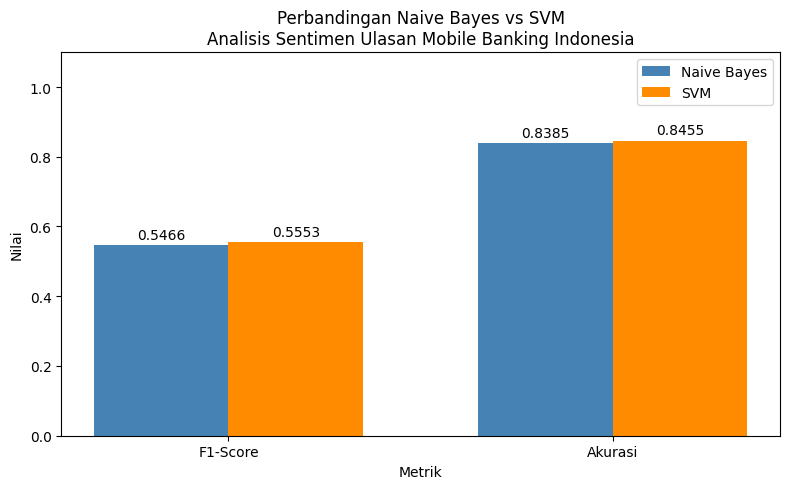

✅ Grafik berhasil disimpan!


In [ ]:
import matplotlib.pyplot as plt

# Data untuk grafik
metrik = ['F1-Score', 'Akurasi']
nilai_nb = [f1_nb, akurasi_nb]
nilai_svm = [f1_svm, akurasi_svm]

x = range(len(metrik))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bar1 = ax.bar([i - width/2 for i in x], nilai_nb, width,
               label='Naive Bayes', color='steelblue')
bar2 = ax.bar([i + width/2 for i in x], nilai_svm, width,
               label='SVM', color='darkorange')

ax.set_xlabel('Metrik')
ax.set_ylabel('Nilai')
ax.set_title('Perbandingan Naive Bayes vs SVM\nAnalisis Sentimen Ulasan Mobile Banking Indonesia')
ax.set_xticks(x)
ax.set_xticklabels(metrik)
ax.set_ylim(0, 1.1)
ax.legend()

# Tambah nilai di atas bar
for bar in bar1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)
for bar in bar2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('grafik_perbandingan.png', dpi=300)
plt.show()
print("✅ Grafik berhasil disimpan!")

In [ ]:
from scipy import stats
import numpy as np

# Jalankan 10 run dengan random_state berbeda
print("Menjalankan 10 eksperimen...")

f1_nb_runs = []
f1_svm_runs = []

for i in range(10):
    # Split data dengan random_state berbeda tiap run
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X, y, test_size=0.2, random_state=i, stratify=y
    )

    # TF-IDF
    tfidf_r = TfidfVectorizer(max_features=5000)
    X_train_tfidf_r = tfidf_r.fit_transform(X_train_r)
    X_test_tfidf_r = tfidf_r.transform(X_test_r)

    # Naive Bayes
    nb_r = MultinomialNB(alpha=1.0)
    nb_r.fit(X_train_tfidf_r, y_train_r)
    pred_nb_r = nb_r.predict(X_test_tfidf_r)
    f1_nb_runs.append(f1_score(y_test_r, pred_nb_r, average='macro'))

    # SVM
    svm_r = SVC(kernel='linear', C=1.0, random_state=42)
    svm_r.fit(X_train_tfidf_r, y_train_r)
    pred_svm_r = svm_r.predict(X_test_tfidf_r)
    f1_svm_runs.append(f1_score(y_test_r, pred_svm_r, average='macro'))

    print(f"Run {i+1}: NB={f1_nb_runs[-1]:.4f} | SVM={f1_svm_runs[-1]:.4f}")

print("\n✅ 10 run selesai!")

Menjalankan 10 eksperimen...
Run 1: NB=0.5542 | SVM=0.5601
Run 2: NB=0.5578 | SVM=0.5691
Run 3: NB=0.5460 | SVM=0.5541
Run 4: NB=0.5599 | SVM=0.5595
Run 5: NB=0.5496 | SVM=0.5617
Run 6: NB=0.5558 | SVM=0.5648
Run 7: NB=0.5544 | SVM=0.5666
Run 8: NB=0.5589 | SVM=0.5671
Run 9: NB=0.5456 | SVM=0.5643
Run 10: NB=0.5495 | SVM=0.5594

✅ 10 run selesai!


In [ ]:
from scipy import stats
import numpy as np

# Wilcoxon signed-rank test
stat, p_value = stats.wilcoxon(f1_svm_runs, f1_nb_runs)

# Effect size Cohen's d
mean_diff = np.mean(f1_svm_runs) - np.mean(f1_nb_runs)
pooled_std = np.sqrt((np.std(f1_svm_runs)**2 + np.std(f1_nb_runs)**2) / 2)
cohens_d = mean_diff / pooled_std if pooled_std != 0 else 0

print("=== HASIL UJI STATISTIK ===")
print(f"Rata-rata F1 Naive Bayes : {np.mean(f1_nb_runs):.4f}")
print(f"Rata-rata F1 SVM         : {np.mean(f1_svm_runs):.4f}")
print(f"Wilcoxon p-value         : {p_value:.4f}")
print(f"Effect size Cohen's d    : {cohens_d:.4f}")
print()

if p_value < 0.05:
    print("✅ H₀ DITOLAK — Perbedaan SVM dan NB SIGNIFIKAN (p < 0.05)")
    print("SVM terbukti lebih baik dari Naive Bayes!")
else:
    print("❌ H₀ GAGAL DITOLAK — Perbedaan TIDAK signifikan (p >= 0.05)")
    print("Tidak cukup bukti bahwa SVM lebih baik dari NB")

# Simpan hasil statistik
hasil_statistik = pd.DataFrame({
    'Run': range(1, 11),
    'F1_NaiveBayes': f1_nb_runs,
    'F1_SVM': f1_svm_runs
})
hasil_statistik.to_csv('hasil_statistik.csv', index=False)
print("\n✅ Hasil statistik disimpan!")

=== HASIL UJI STATISTIK ===
Rata-rata F1 Naive Bayes : 0.5532
Rata-rata F1 SVM         : 0.5627
Wilcoxon p-value         : 0.0039
Effect size Cohen's d    : 2.0479

✅ H₀ DITOLAK — Perbedaan SVM dan NB SIGNIFIKAN (p < 0.05)
SVM terbukti lebih baik dari Naive Bayes!

✅ Hasil statistik disimpan!


In [ ]:
from google.colab import files

files.download('hasil_perbandingan.csv')
files.download('hasil_statistik.csv')
files.download('grafik_perbandingan.png')
print("✅ Semua file berhasil didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Semua file berhasil didownload!


In [ ]:
from google.colab import files

files.download('hasil_statistik.csv')
files.download('grafik_perbandingan.png')
print("✅ Semua file berhasil didownload!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Semua file berhasil didownload!
